# Dating app review analysis

This notebook explores the features produced by `jevdb.py`, which scores
dating app reviews with [Jev](https://docs.typesafe.ai) judgments:

- `content_topic` / `content_topic_confidence` — the review's main topic and
  how concentrated that choice was
- `app_comparison_prob` — probability the review compares its app to another
- `author_male_prob` — probability the review's author is male

The data lives in DuckDB native format at `../data/jevdb.duckdb`. A few things
to keep in mind when reading the numbers:

- A probability near 0.5 means "as likely as not", not "medium".
- Low confidence usually means the review mixes several topics.
- The file reflects the latest `uv run jevdb.py` run's `--min-word-count`
  and `--feature-row-limit`, so re-run that script to refresh the data.

Opening the database: only one process at a time may hold a DuckDB file in
read-write mode. If another program (e.g. DBeaver) has
`../data/jevdb.duckdb` open, connecting fails with a "conflicting lock"
error — close that connection (or open it read-only) first.


In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DB_PATH = Path("../data/jevdb.duckdb")
if not DB_PATH.exists():
    raise FileNotFoundError(
        f"{DB_PATH} not found - run `uv run jevdb.py` first "
        "(requires TYPESAFE_API_KEY) to score reviews and save the tables."
    )

con = duckdb.connect(str(DB_PATH), read_only=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Overview

In [2]:
# Row counts and how many reviews were scored (features only exist for
# reviews that met the word-count threshold at scoring time).
con.sql("""
    SELECT app_name,
           count(*) AS reviews,
           count(*) FILTER (
               WHERE id IN (SELECT id FROM review_features)
           ) AS scored
    FROM reviews
    GROUP BY 1
    ORDER BY 2 DESC
""").df()

,app_name,reviews,scored
0,Hinge,3694,1800
1,Bumble,3562,1639
2,Tinder,3453,1236


In [3]:
con.sql("DESCRIBE review_features").df()

,column_name,column_type,null,key,default,extra
0,id,BIGINT,YES,None,None,None
1,content_topic,VARCHAR,YES,None,None,None
2,content_topic_confidence,DOUBLE,YES,None,None,None
3,app_comparison_prob,DOUBLE,YES,None,None,None
4,author_male_prob,DOUBLE,YES,None,None,None


## Topic distribution

`content_topic` is a single choice among the seven topic options, so each
scored review lands in exactly one bucket.

In [4]:
topics = con.sql("""
    SELECT content_topic,
           count(*) AS reviews,
           round(avg(content_topic_confidence), 3) AS avg_confidence
    FROM review_features
    GROUP BY 1
    ORDER BY 2 DESC
""").df()
topics

,content_topic,reviews,avg_confidence
0,app_bug,967,0.774
1,support_issue,848,0.795
2,scam,729,0.678
3,price,671,0.671
4,dating_success,666,0.741
5,match_quality,431,0.626
6,feature_request,363,0.678


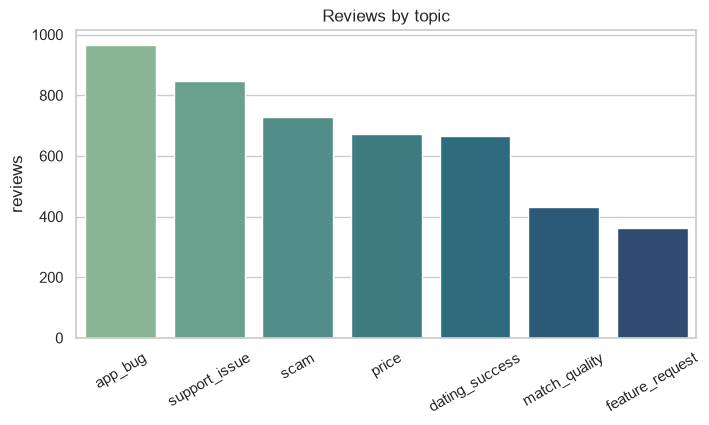

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=topics, x="content_topic", y="reviews",
    hue="content_topic", palette="crest", legend=False, ax=ax,
)
ax.set_title("Reviews by topic")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
plt.show()

In [6]:
topic_by_app = con.sql("""
    SELECT r.app_name, f.content_topic, count(*) AS reviews
    FROM review_features f
    JOIN reviews r USING (id)
    GROUP BY 1, 2
""").df()
topic_by_app.pivot(
    index="content_topic", columns="app_name", values="reviews"
).fillna(0).astype(int)

app_name,Bumble,Hinge,Tinder
content_topic,,,
app_bug,515,234,218
dating_success,169,375,122
feature_request,130,134,99
match_quality,118,215,98
price,204,263,204
scam,249,208,272
support_issue,254,371,223


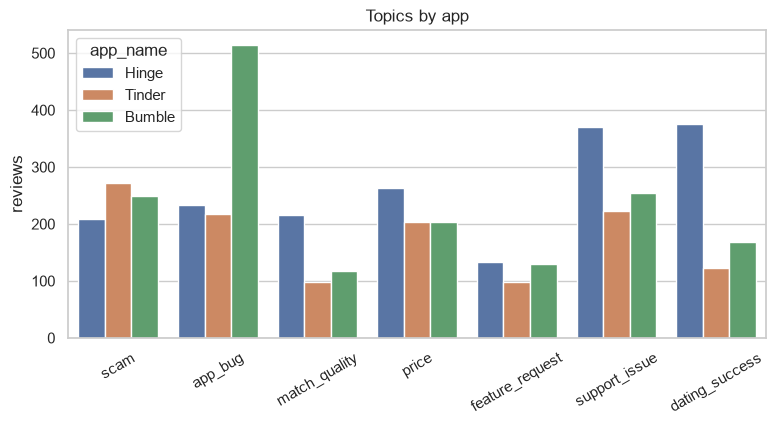

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=topic_by_app, x="content_topic", y="reviews",
    hue="app_name", ax=ax,
)
ax.set_title("Topics by app")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
plt.show()

## Topic confidence

Confidence summarizes how strongly the winning topic beat the alternatives.
Low values flag reviews that mix several topics and may deserve manual
review before being trusted as labels.

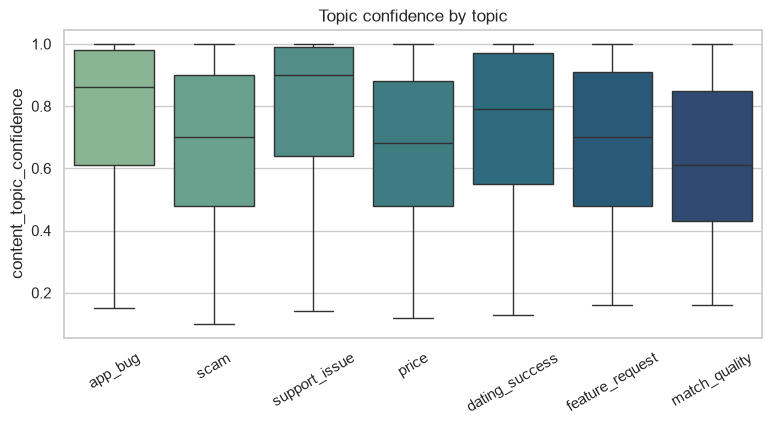

In [8]:
confidence = con.sql("""
    SELECT f.content_topic, f.content_topic_confidence
    FROM review_features f
    JOIN reviews r USING (id)
""").df()

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(
    data=confidence, x="content_topic", y="content_topic_confidence",
    hue="content_topic", palette="crest", legend=False, ax=ax,
)
ax.set_title("Topic confidence by topic")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
plt.show()

## Probability features

Most reviews do not compare apps and do not reveal the author's gender, so
expect mass near the low end and near 0.5 rather than clean separation.

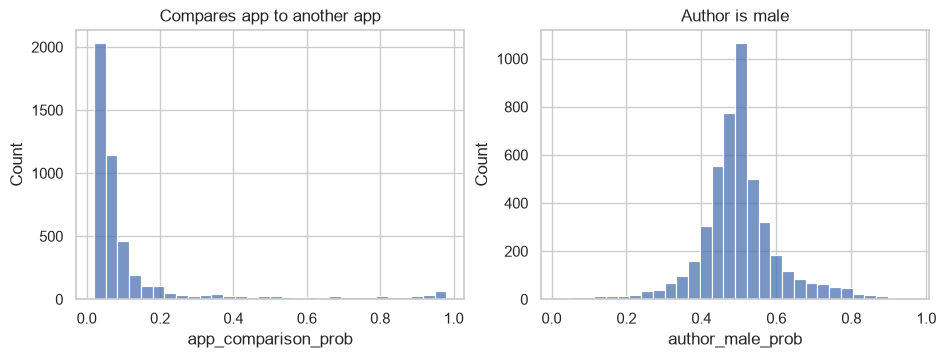

In [9]:
probs = con.sql("""
    SELECT f.app_comparison_prob, f.author_male_prob, r.app_name, r.rating
    FROM review_features f
    JOIN reviews r USING (id)
""").df()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(probs["app_comparison_prob"], bins=30, ax=axes[0])
axes[0].set_title("Compares app to another app")
sns.histplot(probs["author_male_prob"], bins=30, ax=axes[1])
axes[1].set_title("Author is male")
plt.show()

In [10]:
by_topic = con.sql("""
    SELECT content_topic,
           round(avg(app_comparison_prob), 3) AS avg_compare_app,
           round(avg(author_male_prob), 3) AS avg_author_male
    FROM review_features
    GROUP BY 1
    ORDER BY 2 DESC
""").df()
by_topic

,content_topic,avg_compare_app,avg_author_male
0,dating_success,0.171,0.507
1,match_quality,0.166,0.518
2,price,0.164,0.501
3,feature_request,0.155,0.483
4,scam,0.132,0.517
5,support_issue,0.112,0.498
6,app_bug,0.093,0.480


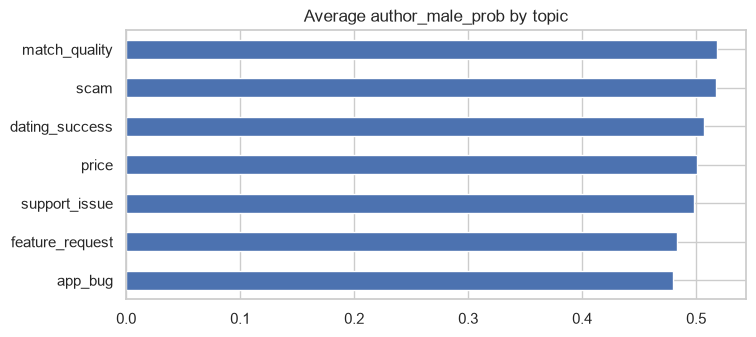

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.5))
by_topic.sort_values("avg_author_male").plot(
    x="content_topic", y="avg_author_male", kind="barh", legend=False, ax=ax
)
ax.set_title("Average author_male_prob by topic")
ax.set_ylabel("")
plt.show()

## Ratings vs. topics

The `reviews` table carries the original star rating, so the scored topics
can be cross-referenced with how angry (or happy) the reviewer was.

In [12]:
con.sql("""
    SELECT f.content_topic,
           count(*) AS reviews,
           round(avg(r.rating), 2) AS avg_rating,
           round(avg((r.sentiment = 'Negative')::INT), 2) AS share_negative
    FROM review_features f
    JOIN reviews r USING (id)
    GROUP BY 1
    ORDER BY avg_rating
""").df()

,content_topic,reviews,avg_rating,share_negative
0,support_issue,848,1.11,0.98
1,scam,729,1.13,0.98
2,app_bug,967,1.31,0.95
3,price,671,1.38,0.94
4,match_quality,431,1.74,0.84
5,feature_request,363,1.81,0.82
6,dating_success,666,2.74,0.56


## Ideas to explore next

- Filter to high-confidence topics only (`content_topic_confidence > 0.8`)
  and see whether the distributions change.
- Look at `app_comparison_prob > 0.7` reviews: what are they comparing?
- Sample reviews by topic and read the raw text to spot-check the labels:
  `con.sql("SELECT r.review_text ... WHERE f.content_topic = 'scam' ...").df()`.
- Refresh the data with `uv run jevdb.py` (see its `--help` for options).